# El Algoritmo Genético desde Cero: Intuición y Mecánica

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/05_algoritmos_geneticos/01_algoritmo_genetico_desde_cero.ipynb)

## Objetivos


- Comprender la analogía biológica detrás de la computación evolutiva y dominar su vocabulario técnico.
- Entender por qué y cuándo los métodos de optimización clásicos (basados en gradiente) fallan al enfrentarse a múltiples óptimos locales.
- Implementar desde cero (en Python puro) el ciclo evolutivo completo: inicialización, evaluación, selección, cruce y mutación.
- Realizar pruebas preliminares para desarrollar intuición sobre el impacto de los hiperparámetros.



## Prerrequisitos


- Conocimientos sólidos de programación en Python y vectorización con NumPy.
- Nociones básicas de cálculo y optimización matemática (máximos, mínimos, gradientes).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

# Importaciones estándar para este notebook
import numpy as np
import matplotlib.pyplot as plt

# Fijamos la semilla para asegurar la reproducibilidad de nuestros experimentos
SEED = 42
rng = np.random.default_rng(SEED)

## Introducción Teórica



La naturaleza lleva miles de millones de años resolviendo un problema de optimización extraordinariamente difícil: encontrar organismos cada vez más adaptados a entornos hostiles y cambiantes. Lo fascinante es que la naturaleza hace esto en espacios de búsqueda de dimensionalidad astronómica y **sin calcular un solo gradiente**.

Charles Darwin observó que tres condiciones son suficientes para que ocurra la evolución:
1. **Variación:** Los individuos de una población difieren entre sí.
2. **Herencia:** Los rasgos ventajosos se transmiten a la descendencia.
3. **Selección:** Los individuos más aptos tienen mayor probabilidad de sobrevivir y reproducirse.

Un **Algoritmo Genético (GA)** es una metaheurística de búsqueda que imita computacionalmente este mecanismo.

¿Por qué lo llamamos *metaheurística*? Porque no nos garantiza matemáticamente encontrar el óptimo global absoluto, pero nos proporciona una estrategia inteligente para explorar espacios de búsqueda complejos, discontinuos o ruidosos donde los métodos tradicionales fallan.

### Vocabulario Técnico Fundamental



Antes de escribir código, necesitamos hablar el mismo idioma. En ingeniería evolutiva, tomamos prestados términos de la biología:

* **Gen:** La unidad mínima de información. En nuestro código, será un número (ej. `0.73`).
* **Cromosoma (o Individuo):** Un vector de genes que representa *una solución candidata* al problema. (ej. `[0.73, -1.24, 0.05]`).
* **Población:** Un conjunto de cromosomas. Si tenemos 50 individuos, tenemos 50 soluciones candidatas evaluándose simultáneamente.
* **Genotipo:** La representación interna de la solución (el array de números).
* **Fenotipo:** La interpretación de ese array en el mundo real (ej. las dimensiones físicas de una viga, o los hiperparámetros de un modelo de Machine Learning).
* **Fitness (Aptitud):** Un valor escalar que mide *qué tan buena* es la solución. A mayor fitness, mejor es el individuo.


## Desarrollo e Implementación



Para entender cómo encajan todas las piezas, vamos a construir un Algoritmo Genético desde cero. Pero primero, necesitamos un problema que resolver.



### 1. El Problema Objetivo



Supongamos que queremos encontrar el valor de $x$ que maximiza la siguiente función matemática en el dominio $[-20, 20]$:

$$ f(x) = \left| \frac{\sin(x)}{x} \right| $$

Esta es una variante de la función *sinc*, muy conocida en procesamiento de señales. Vamos a definirla y graficarla.

> ⚠️ **Criterio de Ingeniería:** Matemáticamente, la división por cero en $x=0$ está indefinida, aunque el límite es $1$. Computacionalmente, `np.sin(0)/0` arrojará un `RuntimeWarning` y un valor `NaN` (Not a Number), lo cual arruinaría nuestro algoritmo. Debemos manejar este caso límite explícitamente.

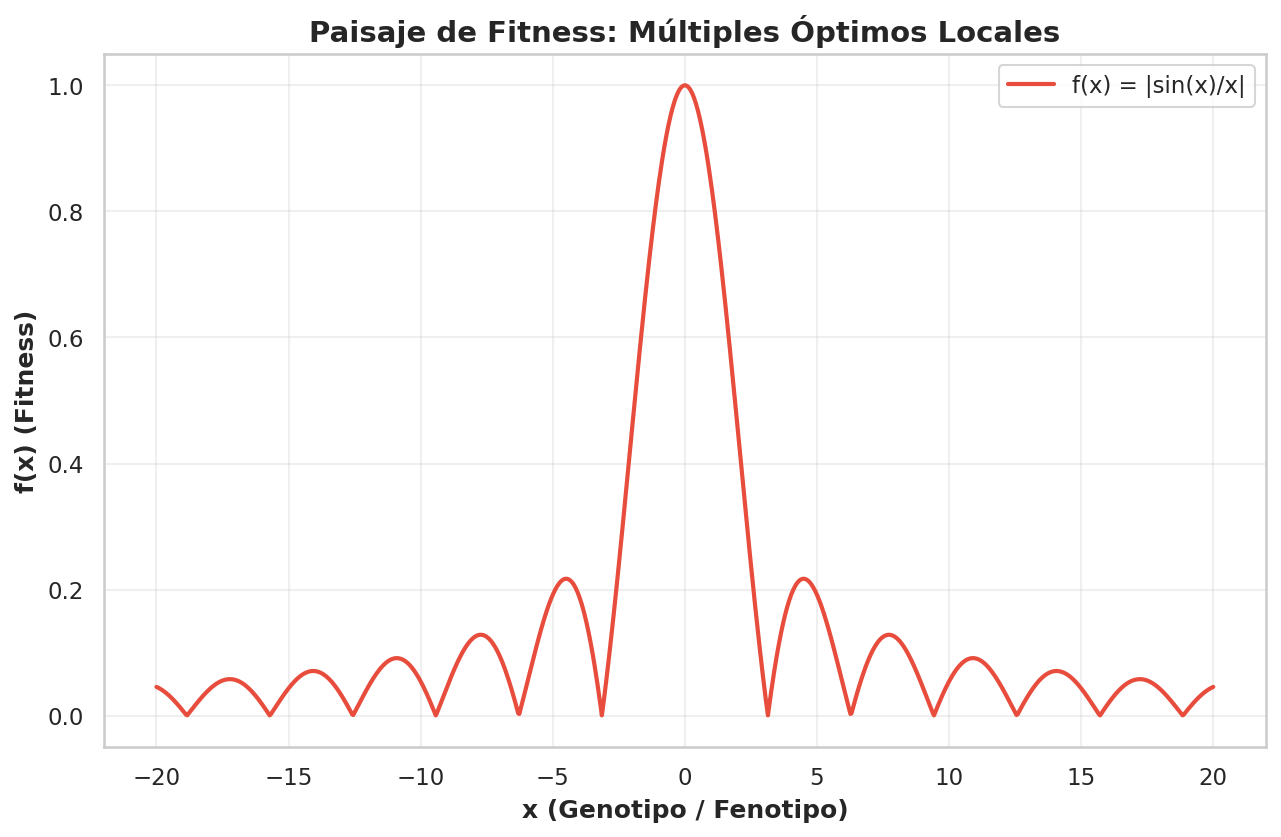

In [2]:
def funcion_objetivo(x):
    """
    La función tiene muchos máximos locales.
    El máximo global se encuentra en: f(0) = 1
    """
    # Manejo seguro de la división por cero
    x_safe = np.where(x == 0, 1e-10, x)
    f = np.abs(np.sin(x_safe) / x_safe)
    return f

# Definimos el dominio
X_MIN, X_MAX = -20.0, 20.0
x_plot = np.linspace(X_MIN, X_MAX, 1000)
y_plot = funcion_objetivo(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, label='f(x) = |sin(x)/x|', color='#e74c3c', linewidth=2)
plt.title("Paisaje de Fitness: Múltiples Óptimos Locales")
plt.xlabel("x (Genotipo / Fenotipo)")
plt.ylabel("f(x) (Fitness)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Observar la gráfica. Si usáramos un algoritmo de **Descenso de Gradiente** (o ascenso, en este caso) y empezáramos aleatoriamente en $x = 15$, el algoritmo subiría la colina más cercana (alrededor de $x \approx 14$) y se quedaría atrapado allí para siempre, creyendo que encontró la mejor solución posible. A esto lo llamamos un **óptimo local**.

El Algoritmo Genético, al mantener una *población* de múltiples puntos distribuidos por todo el espacio, puede saltar entre colinas y tiene muchas más probabilidades de encontrar el **óptimo global** en $x=0$.

### 2. Inicialización de la Población



El primer paso es crear nuestra población inicial. Generamos individuos con valores aleatorios dentro de nuestro dominio $[-20, 20]$.

In [3]:
def inicializar_poblacion(n_individuos, n_genes, x_min, x_max, rng):
    """
    Crea una población inicial con valores reales distribuidos uniformemente.

    - n_individuos: Tamaño de la población (N).
    - n_genes: Dimensionalidad del problema (D).
    - x_min, x_max: Límites del espacio de búsqueda.
    """
    return rng.uniform(low=x_min, high=x_max, size=(n_individuos, n_genes))

N_INDIVIDUOS = 50
N_GENES = 1 # Nuestro problema es 1D

poblacion = inicializar_poblacion(N_INDIVIDUOS, N_GENES, X_MIN, X_MAX, rng)
print(f"Población creada con forma: {poblacion.shape}")
print(f"Primeros 3 individuos:\n{poblacion[:3]}")

Población creada con forma: (50, 1)
Primeros 3 individuos:
[[10.95824194]
 [-2.44486241]
 [14.3439168 ]]


### 3. Evaluación (Fitness)



Necesitamos evaluar qué tan bueno es cada individuo. En este problema simple, el fenotipo es igual al genotipo (el valor de $x$), y el fitness es simplemente el resultado de evaluar $f(x)$.



In [4]:
def evaluar_poblacion(poblacion):
    """
    Calcula el fitness de cada individuo en la población.
    """
    # Extraemos la primera columna (nuestro único gen) y evaluamos
    x_valores = poblacion[:, 0]
    return funcion_objetivo(x_valores)

fitness = evaluar_poblacion(poblacion)
print(f"Fitness del primer individuo (x={poblacion[0][0]:.3f}): {fitness[0]:.3f}")

Fitness del primer individuo (x=10.958): 0.091


### 4. Selección por Torneo



Ahora debemos decidir quiénes se reproducen. Si solo elegimos a los mejores, la población perderá diversidad rápidamente y colapsará en un óptimo local. Si elegimos aleatoriamente, no habrá evolución.

La **Selección por Torneo** es el estándar de la industria porque ofrece un balance perfecto. Elegimos $k$ individuos al azar de la población y los hacemos "competir". El que tiene mayor fitness gana y se convierte en padre.



In [5]:
def seleccion_torneo(poblacion, fitness, k=3, rng=None):
    """
    Selecciona padres mediante torneos de tamaño k.

    - k: Presión selectiva. Un k mayor favorece fuertemente a los mejores.
    """
    n = len(poblacion)
    padres = np.empty_like(poblacion)

    for i in range(n):
        # Elegimos k competidores al azar
        competidores_idx = rng.integers(0, n, size=k)
        # El ganador es el índice con el máximo fitness entre los competidores
        ganador_idx = competidores_idx[np.argmax(fitness[competidores_idx])]
        padres[i] = poblacion[ganador_idx]

    return padres

### 5. Cruce (Crossover)


El cruce combina la información de dos padres para crear descendencia. Como nuestros genes son números reales (no binarios), usamos un **Cruce Aritmético**.

Si tenemos dos padres $p_1$ y $p_2$, creamos dos hijos $h_1$ y $h_2$ interpolando un punto aleatorio $\alpha$ entre ellos:
$$ h_1 = \alpha p_1 + (1 - \alpha) p_2 $$
$$ h_2 = (1 - \alpha) p_1 + \alpha p_2 $$


In [6]:
def cruzar_poblacion(padres, p_cruce, rng):
    """
    Aplica cruce aritmético a pares consecutivos de padres.

    - p_cruce: Probabilidad de que ocurra el cruce (típicamente 0.7 - 0.9).
    """
    n = len(padres)
    descendencia = np.empty_like(padres)

    for i in range(0, n - 1, 2):
        p1, p2 = padres[i], padres[i+1]

        if rng.random() < p_cruce:
            alpha = rng.random()
            descendencia[i]   = alpha * p1 + (1 - alpha) * p2
            descendencia[i+1] = (1 - alpha) * p1 + alpha * p2
        else:
            # Si no hay cruce, los hijos son clones exactos de los padres
            descendencia[i]   = p1.copy()
            descendencia[i+1] = p2.copy()

    # Si la población es impar, el último pasa directo
    if n % 2 == 1:
        descendencia[-1] = padres[-1].copy()

    return descendencia

### 6. Mutación



El cruce solo puede interpolar entre valores que ya existen en la población. Para descubrir nuevas regiones del espacio de búsqueda, necesitamos la **Mutación**. Añadimos un pequeño ruido Gaussiano a los genes con una probabilidad $p_{mut}$.


In [7]:
def mutar_poblacion(descendencia, p_mutacion, sigma, x_min, x_max, rng):
    """
    Aplica mutación gaussiana a los individuos.

    - p_mutacion: Probabilidad de que un individuo sufra mutación.
    - sigma: Desviación estándar del ruido (tamaño del "paso" de exploración).
    """
    mutados = descendencia.copy()
    n, n_genes = mutados.shape

    for i in range(n):
        if rng.random() < p_mutacion:
            ruido = rng.normal(0, sigma, size=n_genes)
            mutados[i] += ruido
            # Es vital hacer "clipping" para no salirnos del dominio del problema
            mutados[i] = np.clip(mutados[i], x_min, x_max)

    return mutados

### 7. Elitismo y Reemplazo



Finalmente, la nueva descendencia reemplaza a la población anterior. Sin embargo, por puro azar, el cruce y la mutación podrían destruir al mejor individuo que habíamos encontrado. Para evitar esto, usamos **Elitismo**: copiamos intactos a los $N$ mejores individuos de la generación anterior directamente a la nueva.



In [8]:
def reemplazar_con_elitismo(poblacion_actual, fitness_actual, nueva_generacion, n_elite=1):
    """
    Asegura que los mejores individuos sobrevivan a la siguiente generación.
    """
    siguiente_gen = nueva_generacion.copy()

    if n_elite > 0:
        # Índices de los mejores padres
        indices_elite = np.argsort(fitness_actual)[::-1][:n_elite]

        # Evaluamos a los hijos para encontrar a los peores
        fitness_nueva = evaluar_poblacion(nueva_generacion)
        indices_peores = np.argsort(fitness_nueva)[:n_elite]

        # Reemplazamos a los peores hijos con los mejores padres
        for i, idx_elite in enumerate(indices_elite):
            siguiente_gen[indices_peores[i]] = poblacion_actual[idx_elite].copy()

    return siguiente_gen

### 8. Ensamblando el Ciclo Completo



Ahora encapsulamos todo en una función maestra que ejecutará el ciclo evolutivo durante $G$ generaciones.



In [9]:
def ejecutar_ga(n_generaciones=100, n_individuos=50, p_cruce=0.85, p_mutacion=0.1, sigma=1.0, n_elite=1, seed=42):
    rng_local = np.random.default_rng(seed)

    # 1. Inicialización
    poblacion = inicializar_poblacion(n_individuos, 1, X_MIN, X_MAX, rng_local)
    fitness = evaluar_poblacion(poblacion)

    # Para guardar métricas
    historial_mejor = np.zeros(n_generaciones)
    historial_media = np.zeros(n_generaciones)

    for gen in range(n_generaciones):
        # Guardamos métricas
        historial_mejor[gen] = fitness.max()
        historial_media[gen] = fitness.mean()

        # 2. Selección
        padres = seleccion_torneo(poblacion, fitness, k=3, rng=rng_local)

        # 3. Cruce
        descendencia = cruzar_poblacion(padres, p_cruce, rng_local)

        # 4. Mutación
        descendencia = mutar_poblacion(descendencia, p_mutacion, sigma, X_MIN, X_MAX, rng_local)

        # 5. Reemplazo con Elitismo
        poblacion = reemplazar_con_elitismo(poblacion, fitness, descendencia, n_elite)

        # 6. Re-evaluación para el siguiente ciclo
        fitness = evaluar_poblacion(poblacion)

    mejor_idx = fitness.argmax()
    return poblacion[mejor_idx], fitness[mejor_idx], historial_mejor, historial_media, poblacion

# ¡Ejecutamos nuestro Algoritmo Genético!
mejor_ind, mejor_fit, hist_mejor, hist_media, pob_final = ejecutar_ga(n_generaciones=10, n_individuos=10, p_mutacion=0.15)

print(f"Óptimo real: x = 0.0000, f(x) = 1.0000")
print(f"Óptimo GA:   x = {mejor_ind[0]:.4f}, f(x) = {mejor_fit:.4f}")

Óptimo real: x = 0.0000, f(x) = 1.0000
Óptimo GA:   x = -0.0192, f(x) = 0.9999


## Resultados y Discusión



Vamos a visualizar qué ocurrió durante esas 50 generaciones. Analizamos dos cosas: la curva de convergencia y dónde terminó ubicada nuestra población final.



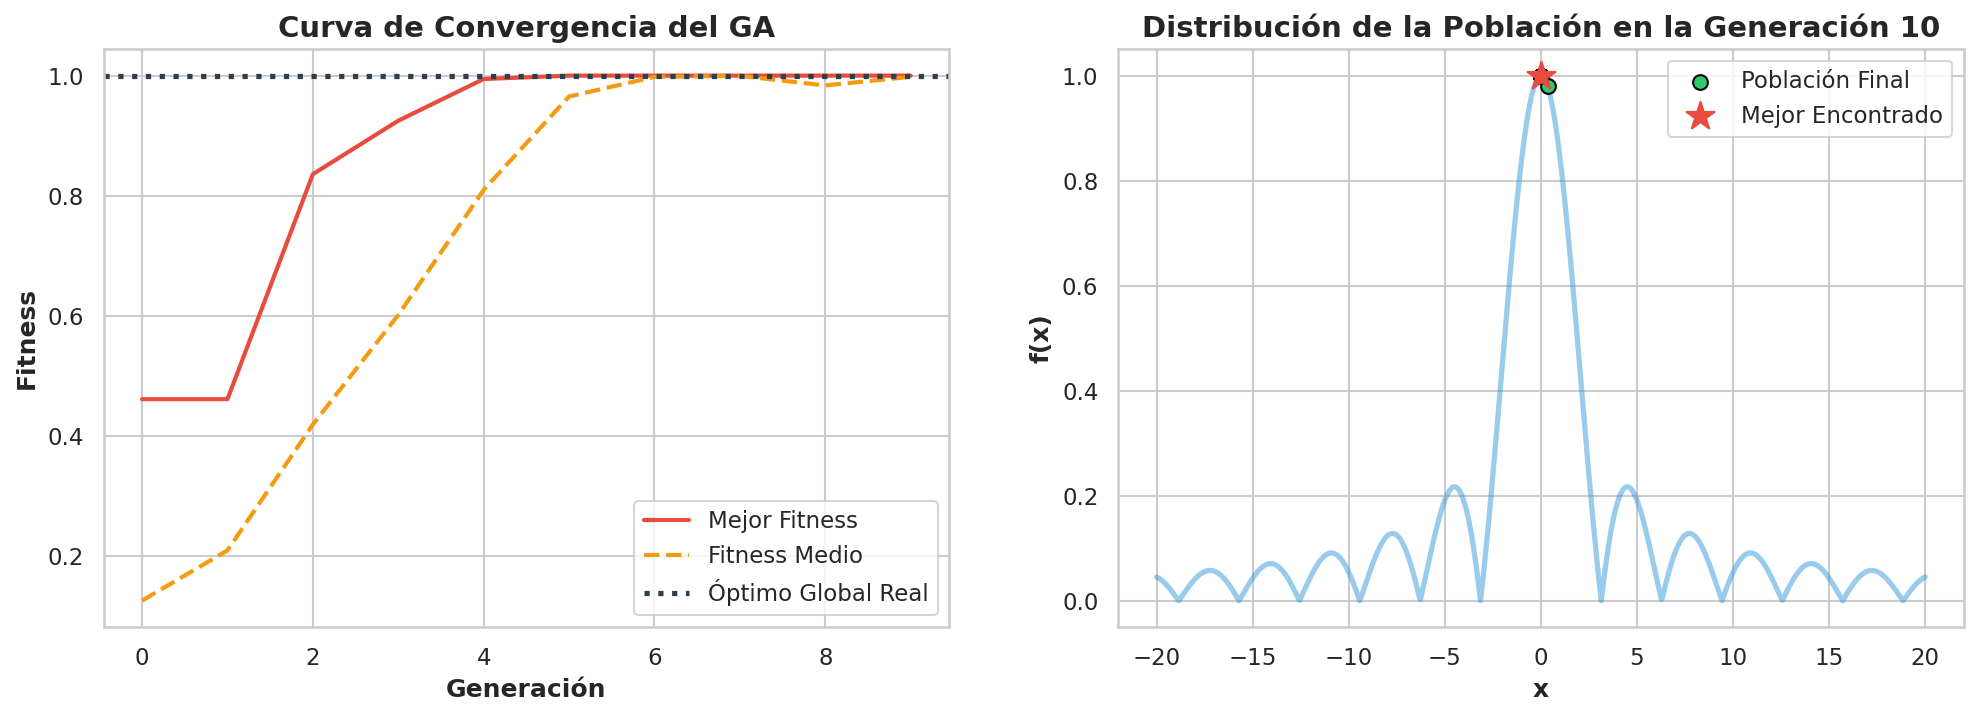

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Curva de Convergencia
ax1.plot(hist_mejor, label='Mejor Fitness', color='#e74c3c', linewidth=2)
ax1.plot(hist_media, label='Fitness Medio', color='#f39c12', linestyle='--', linewidth=2)
ax1.axhline(1.0, color='#2c3e50', linestyle=':', label='Óptimo Global Real')
ax1.set_title("Curva de Convergencia del GA")
ax1.set_xlabel("Generación")
ax1.set_ylabel("Fitness")
ax1.legend()

# Gráfico 2: Población Final
ax2.plot(x_plot, y_plot, color='#3498db', alpha=0.5)
ax2.scatter(pob_final[:, 0], evaluar_poblacion(pob_final), color='#2ecc71', edgecolor='black', s=50, label='Población Final', zorder=3)
ax2.scatter([mejor_ind[0]], [mejor_fit], color='#e74c3c', marker='*', s=200, label='Mejor Encontrado', zorder=4)
ax2.set_title("Distribución de la Población en la Generación 10")
ax2.set_xlabel("x")
ax2.set_ylabel("f(x)")
ax2.legend()

plt.show()

### ¿Qué nos dicen estos gráficos?



1. **La Curva de Convergencia (Izquierda):**
   * Observar cómo la línea roja (Mejor Fitness) sube en forma de "escalones". Esto ocurre cuando la mutación o el cruce descubren un nuevo pico, y gracias al *Elitismo*, ese valor nunca decae.
   * La línea amarilla (Fitness Medio) sigue a la roja pero con un margen inferior. Esto es sano: significa que la población mantiene cierta diversidad y no son todos clones exactos del mejor individuo.
2. **La Población Final (Derecha):**
   * Notar cómo la gran mayoría de los puntos verdes se han aglomerado alrededor del pico central (el óptimo global). El algoritmo logró escapar de las trampas de los picos laterales.


## Pequeñas Pruebas: Construyendo Intuición



Para sentar las bases del próximo notebook, hagamos un pequeño experimento. ¿Qué pasa si configuramos mal nuestro algoritmo?

Vamos a simular un escenario de **Convergencia Prematura**. Reducimos drásticamente el tamaño de la población (poca diversidad inicial) y bajamos la tasa de mutación casi a cero (poca exploración).


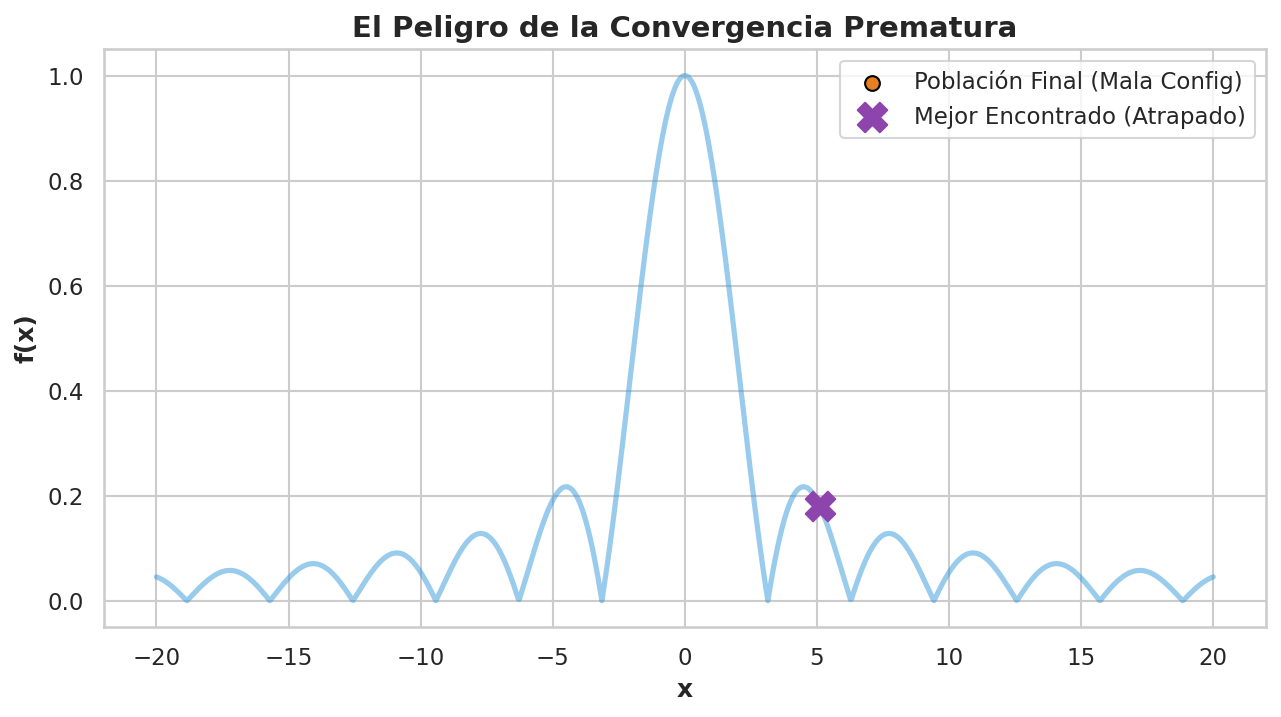

Óptimo encontrado con mala configuración: x = 5.1058, f(x) = 0.1809


In [11]:
# Experimento: Mala configuración (Poca población, casi nula mutación)
mejor_ind_malo, mejor_fit_malo, hist_mejor_malo, _, pob_final_mala = ejecutar_ga(
    n_generaciones=10,
    n_individuos=4,    # ¡Población muy pequeña!
    p_mutacion=0.01,   # ¡Casi no hay mutación!
    seed=12
)

plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_plot, color='#3498db', alpha=0.5)
plt.scatter(pob_final_mala[:, 0], evaluar_poblacion(pob_final_mala), color='#e67e22', edgecolor='black', s=50, label='Población Final (Mala Config)', zorder=3)
plt.scatter([mejor_ind_malo[0]], [mejor_fit_malo], color='#8e44ad', marker='X', s=200, label='Mejor Encontrado (Atrapado)', zorder=4)
plt.title("El Peligro de la Convergencia Prematura")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

print(f"Óptimo encontrado con mala configuración: x = {mejor_ind_malo[0]:.4f}, f(x) = {mejor_fit_malo:.4f}")

**Análisis del fallo:** Al tener tan pocos individuos, es probable que ninguno haya caído cerca del pico central al inicio. Al no haber mutación suficiente, el algoritmo no tuvo forma de "saltar" hacia el centro. Simplemente cruzó a los individuos existentes, escalando la colina lateral más cercana y quedándose atrapado allí.

Este experimento demuestra empíricamente que **los hiperparámetros dictan el éxito o fracaso del algoritmo**.

## Experimentación Interactiva: Evolución en Vivo

La mejor forma de entender un sistema dinámico es interactuando con él. Hemos visto qué pasa con una buena y una mala configuración, pero ahora vamos a visualizar el proceso evolutivo **en tiempo real**.

A continuación, construimos un panel interactivo utilizando `ipywidgets`. Se puede ajustar el tamaño de la población, la cantidad de generaciones, la probabilidad de mutación y el tamaño del paso de mutación ($\sigma$).


**Instrucciones de uso:**
1. Ajustar los hiperparámetros en el panel superior.
2. Presionar **"Calcular Evolución"**. El algoritmo correrá en segundo plano y guardará la historia de todas las generaciones.
3. Aparecerá un reproductor. Usar el botón de **Play/Pausa** o arrastrar el **control deslizante** para navegar libremente por cualquier generación y analizar cómo se movió la población.


In [25]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# 1. Controles de hiperparámetros
pop_slider = widgets.IntSlider(value=30, min=10, max=100, step=10, description='Población:')
gen_slider = widgets.IntSlider(value=50, min=10, max=200, step=10, description='Generaciones:')
mut_slider = widgets.FloatSlider(value=0.15, min=0.0, max=1.0, step=0.05, description='Prob. Mutación:')
sig_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Sigma (σ):')
run_button = widgets.Button(description='Calcular y Animar', button_style='primary', layout=widgets.Layout(width='200px'))
status_label = widgets.Label(value="Ajustar los parámetros y presionar el botón.")

ui_params = widgets.VBox([
    widgets.HBox([pop_slider, gen_slider]),
    widgets.HBox([mut_slider, sig_slider]),
    widgets.HBox([run_button, status_label])
])

output_anim = widgets.Output()

# 2. Lógica principal y Animación
def run_ga_and_animate(b):
    with output_anim:
        clear_output(wait=True)
        run_button.disabled = True
        status_label.value = "Calculando evolución..."

        # Capturamos parámetros
        N = pop_slider.value
        G = gen_slider.value
        P_MUT = mut_slider.value
        SIGMA = sig_slider.value
        P_CRUCE = 0.85

        # Ejecutamos el GA guardando la historia
        rng_local = np.random.default_rng(SEED)
        pob = inicializar_poblacion(N, 1, X_MIN, X_MAX, rng_local)
        fit = evaluar_poblacion(pob)

        historia_pob = [pob.copy()]
        historia_fit = [fit.copy()]
        historia_mejor = [fit.max()]
        historia_media = [fit.mean()]

        for gen in range(G):
            padres = seleccion_torneo(pob, fit, k=3, rng=rng_local)
            desc = cruzar_poblacion(padres, P_CRUCE, rng_local)
            desc = mutar_poblacion(desc, P_MUT, SIGMA, X_MIN, X_MAX, rng_local)
            pob = reemplazar_con_elitismo(pob, fit, desc, n_elite=1)
            fit = evaluar_poblacion(pob)

            historia_pob.append(pob.copy())
            historia_fit.append(fit.copy())
            historia_mejor.append(fit.max())
            historia_media.append(fit.mean())

        status_label.value = "Generando reproductor de video (esto puede tomar unos segundos)..."

        # --- Configuración de la Animación ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        plt.close(fig) # Evita que se dibuje una gráfica estática extra

        def update(frame):
            ax1.clear()
            ax2.clear()

            pob_f = historia_pob[frame]
            fit_f = historia_fit[frame]

            # Panel Izquierdo: Paisaje y Población
            ax1.plot(x_plot, y_plot, color='#e74c3c', alpha=0.4, linewidth=2)
            ax1.scatter(pob_f[:, 0], fit_f, color='#2ecc71', edgecolor='black', s=60, zorder=3, alpha=0.8)
            mejor_idx = fit_f.argmax()
            ax1.scatter([pob_f[mejor_idx, 0]], [fit_f[mejor_idx]], color='#8e44ad', marker='*', s=250, zorder=4)
            ax1.set_title(f"Población en el Espacio de Búsqueda - Gen {frame}/{G}")
            ax1.set_xlabel("x")
            ax1.set_ylabel("f(x)")
            ax1.set_xlim(X_MIN, X_MAX)
            ax1.set_ylim(-0.05, 1.1)
            ax1.grid(True, alpha=0.3)

            # Panel Derecho: Métricas de Progreso
            ax2.plot(range(frame+1), historia_mejor[:frame+1], color='#e74c3c', label='Mejor Fitness', linewidth=2)
            ax2.plot(range(frame+1), historia_media[:frame+1], color='#f39c12', linestyle='--', label='Fitness Medio', linewidth=2)
            ax2.set_title("Curvas de Convergencia")
            ax2.set_xlabel("Generación")
            ax2.set_ylabel("Fitness")
            ax2.set_xlim(0, G)
            ax2.set_ylim(-0.05, 1.1)
            ax2.legend(loc='lower right')
            ax2.grid(True, alpha=0.3)

        # Creamos la animación
        anim = animation.FuncAnimation(fig, update, frames=G+1, interval=150, blit=False)

        # Convertimos a HTML interactivo y lo mostramos
        html_anim = anim.to_jshtml()
        display(HTML(html_anim))

        status_label.value = f"¡Listo! Mejor fitness: {fit.max():.4f} en x = {pob[fit.argmax(), 0]:.4f}"
        run_button.disabled = False

run_button.on_click(run_ga_and_animate)

# Mostramos la interfaz
display(ui_params, output_anim)

Output()

> *Intentar lo siguiente:*
> * **El efecto del Sigma:** Un $\sigma$ muy alto (ej. `4,0`). Los puntos saltan erráticamente y la curva de fitness medio colapsa. ¿Tiene sentido?
> * **El efecto de la Mutación:** Mutación en `0,0`. ¿La población se estanca rápidamente en el primer pico que encuentra? ¿Tiene sentido?

## Conexiones y Próximos Pasos



Acabamos de construir un motor evolutivo completo desde cero. Entender esta mecánica interna es lo que separa a un usuario de librerías de un verdadero ingeniero de IA. Notar además que, la implementación de este tipo de algoritmos suele ser simple, pero a la vez, permite (y vamos a descubrirlo) resolver problemas muy difíciles. Convirtiéndolo en un candidato plausible de ser implementado incluso en hardware embebido, por dar un ejemplo.

Sin embargo, como vimos en nuestra última prueba, elegir los valores correctos para la población, el cruce y la mutación no es trivial. En el próximo notebook, formalizaremos este estudio.

- ➡️ **Siguiente:** [Exploración de Operadores y el Teorema "*No Free Lunch*"](02_operadores_y_benchmarks.ipynb)
- 🔄 **Relacionado:** [Introducción a DEAP: Infraestructura Evolutiva en Python](03_framework_deap_y_paralelizacion.ipynb)


## Referencias


1. **Holland, J. H. (1992).** *Adaptation in natural and artificial systems*. MIT press. *(El libro fundacional que introdujo formalmente los Algoritmos Genéticos al mundo computacional).*
2. **Eiben, A. E., & Smith, J. E. (2015).** *Introduction to evolutionary computing*. Springer. *(Excelente texto moderno que detalla las diferencias entre representaciones reales, binarias y permutacionales).*
3. **Goldberg, D. E. (1989).** *Genetic Algorithms in Search, Optimization, and Machine Learning*. Addison-Wesley. *(Lectura obligatoria para entender la teoría de esquemas y por qué el cruce funciona matemáticamente).*

---


## Entorno de Ejecución


In [13]:
from utils.environment import environment_table
environment_table()

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
statsmodels,0.14.6


```
